
# Model Comparison: Linear Regression, Bayesian Ridge Regression, and MLP

## Objective

This notebook compares three regression approaches for predicting median house values in the California Housing dataset:

1. **Linear Regression**
2. **Bayesian Ridge Regression**
3. **Multilayer Perceptron (MLP)**

The comparison focuses on both predictive performance and model behavior.  
All final metrics are reported on the held-out **test set**, which was not used during training or validation-based model selection.



# 1. Setup

The project code is stored in the `src/` directory.  
Because this notebook is expected to live inside the `notebooks/` folder, the project root is added to the Python path before importing project modules.


In [1]:

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))



# 2. Final Test Metrics

The following metrics were obtained from `main.py`, after training each model and evaluating once on the unseen test set.

The target variable, `MedHouseValue`, is expressed in units of **$100,000**.  
For example, an RMSE of `0.50` corresponds to an approximate prediction error of **$50,000**.


In [2]:

results = {
    "Linear Regression": {
        "mse": 0.43582443808312427,
        "rmse": 0.6601700069551208,
        "mae": 0.4877801710705147,
        "r2": 0.6647506581008154
    },
    "Bayesian Ridge Regression": {
        "mse": 0.435831977865155,
        "rmse": 0.6601757174155642,
        "mae": 0.48778319796906294,
        "r2": 0.6647448582723914
    },
    "MLP": {
        "mse": 0.24733184278011322,
        "rmse": 0.49732468547229103,
        "mae": 0.3349144160747528,
        "r2": 0.8097448348999023
    }
}

metrics_df = pd.DataFrame(results).T
metrics_df


,mse,rmse,mae,r2
Linear Regression,0.435824,0.660170,0.487780,0.664751
Bayesian Ridge Regression,0.435832,0.660176,0.487783,0.664745
MLP,0.247332,0.497325,0.334914,0.809745



## Initial Interpretation

The results show a clear performance separation between the linear models and the neural network.

The two linear models perform almost identically, while the MLP achieves substantially lower error and a higher R² score. This indicates that the main limitation of the linear approaches is not simply regularization, but the assumption that the target can be represented well as a linear combination of the input features.

Housing values are influenced by nonlinear interactions between income, geography, household characteristics, and population-related variables. The MLP is better suited to capture these patterns.



# 3. Metric Comparison


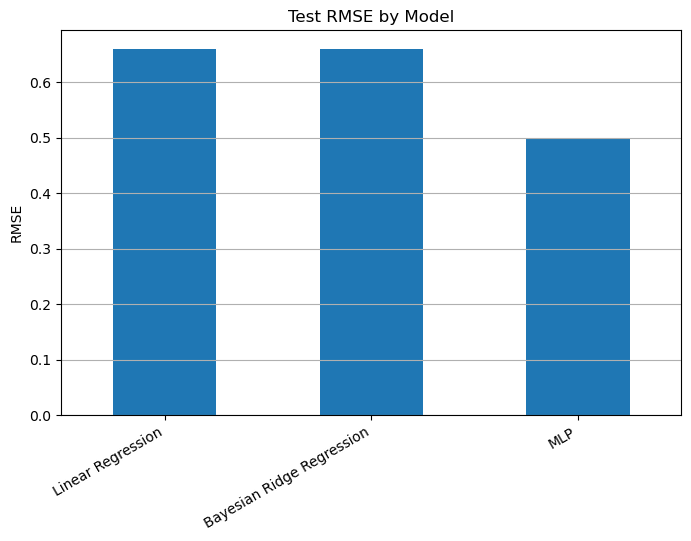

In [3]:

plt.figure(figsize=(8, 5))
metrics_df["rmse"].plot(kind="bar")
plt.ylabel("RMSE")
plt.title("Test RMSE by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()



## RMSE

The MLP achieves the lowest RMSE:

- Linear Regression: approximately **$66,000**
- Bayesian Ridge Regression: approximately **$66,000**
- MLP: approximately **$50,000**

This improvement is meaningful because RMSE penalizes larger prediction errors more strongly.


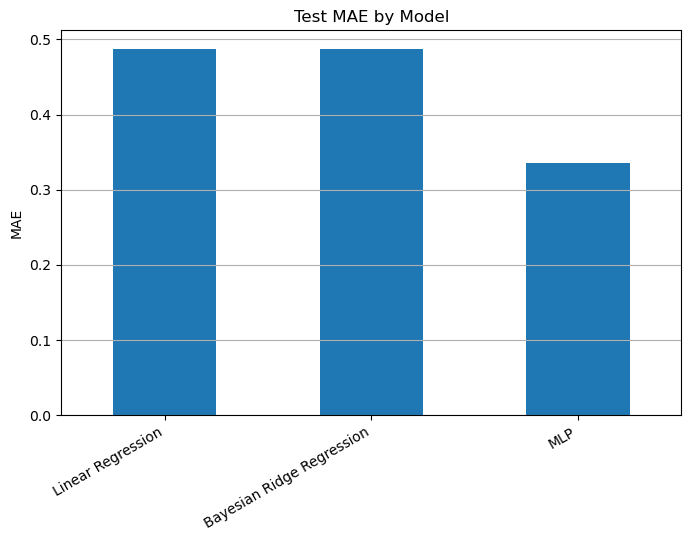

In [4]:

plt.figure(figsize=(8, 5))
metrics_df["mae"].plot(kind="bar")
plt.ylabel("MAE")
plt.title("Test MAE by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()



## MAE

The MLP also achieves the lowest MAE, indicating that its average absolute prediction error is lower than both linear alternatives.


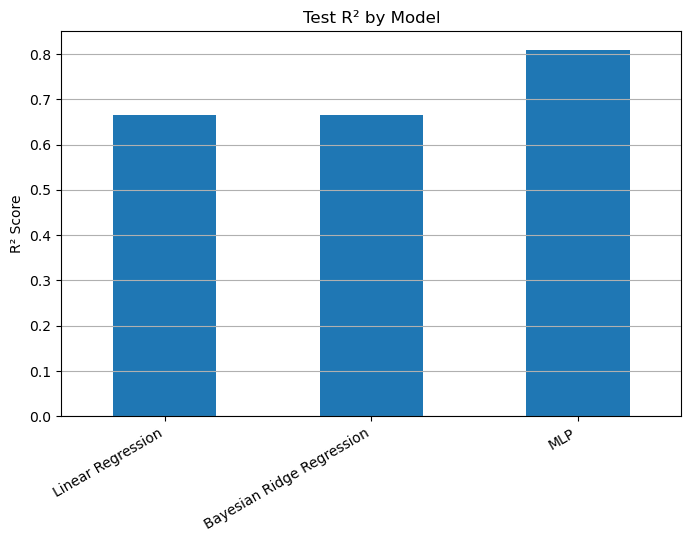

In [5]:

plt.figure(figsize=(8, 5))
metrics_df["r2"].plot(kind="bar")
plt.ylabel("R² Score")
plt.title("Test R² by Model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()



## R²

The MLP explains approximately **81%** of the variance in the test set, compared with approximately **66%** for the linear models.

This supports the conclusion that the dataset contains nonlinear structure that simple linear models cannot fully represent.



# 4. Prediction vs Actual Analysis

The following plots compare predicted values against actual values.

A perfect model would place all points on the diagonal line.  
Larger deviations from the diagonal indicate larger prediction errors.



## Linear Regression

![Linear Regression Predictions](../reports/predicted_vs_actual_lr.png)

The Linear Regression model captures the broad positive relationship between features and house value, but the spread around the diagonal is large. This is especially visible in higher-value districts, where the model struggles to represent the underlying structure.



## Bayesian Ridge Regression

![Bayesian Ridge Predictions](../reports/predicted_vs_actual_blr.png)

Bayesian Ridge Regression shows almost the same prediction pattern as standard Linear Regression. This is expected because it remains a linear model.

Its value is not higher predictive accuracy in this case, but its ability to provide uncertainty estimates for predictions.



## MLP

![MLP Predictions](../reports/predicted_vs_actual_mlp.png)

The MLP predictions align more closely with the diagonal line. The model captures nonlinear structure more effectively and performs better across much of the target range.



# 5. Residual Analysis

Residuals are defined as:

```text
residual = actual value - predicted value
```

A strong model should produce residuals that are centered around zero and do not show clear systematic patterns.



## Linear Regression Residuals

![Linear Regression Residuals](../reports/residual_plot_lp.png)

The residuals display visible structure, suggesting that the model misses important nonlinear relationships. The shape is also affected by the capped target value identified during EDA.



## Bayesian Ridge Regression Residuals

![Bayesian Ridge Residuals](../reports/residual_plot_blp.png)

The Bayesian Ridge residual pattern is nearly identical to Linear Regression. This reinforces the conclusion that Bayesian Ridge does not remove the core limitation of a linear functional form.



## MLP Residuals

![MLP Residuals](../reports/residual_plot_mlp.png)

The MLP residuals are more concentrated around zero, indicating better predictive accuracy. Some residual structure remains, which is expected because the dataset contains capped targets and complex geographic effects.



# 6. MLP Training Dynamics

![MLP Training and Validation Loss](../reports/train_validation_mlp.png)

The training and validation curves decrease steadily and remain relatively close throughout training.

This suggests:
- stable optimization,
- effective regularization,
- and no strong evidence of overfitting.

The validation loss staying below the training loss is not necessarily problematic here because dropout is active during training and disabled during evaluation.



# 7. Bayesian Uncertainty

Bayesian Ridge Regression is not expected to outperform the MLP or even necessarily outperform ordinary Linear Regression in accuracy.

Its main advantage is that it can quantify uncertainty.

Unlike standard Linear Regression, which returns only a point prediction, Bayesian Ridge can return:

- a predicted value,
- and a standard deviation representing predictive uncertainty.

This makes the model useful when we care not only about *what* it predicts, but also about *how confident* it is.


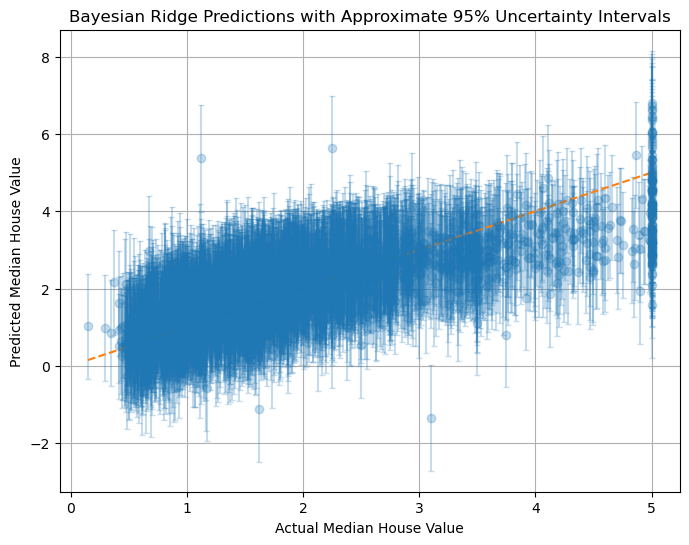

In [6]:

# Optional: Bayesian uncertainty visualization.
# This cell requires the project src/ files and should be run from the notebooks/ directory.

from src.preprocessing import prepare_data
from src.bayesian_regression import (
    train_bayesian_regression,
    evaluate_bayesian_regression,
)

data = prepare_data()

bayesian_model = train_bayesian_regression(
    data["X_train_scaled"],
    data["y_train"]
)

bayesian_test = evaluate_bayesian_regression(
    bayesian_model,
    data["X_test_scaled"],
    data["y_test"]
)

y_true = data["y_test"]
y_pred = bayesian_test["predictions"]
y_std = bayesian_test["uncertainty_std"]

plt.figure(figsize=(8, 6))

plt.errorbar(
    y_true,
    y_pred,
    yerr=2 * y_std,
    fmt="o",
    alpha=0.25,
    capsize=2
)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    linestyle="--"
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Bayesian Ridge Predictions with Approximate 95% Uncertainty Intervals")
plt.grid(True)
plt.show()



## Interpreting Bayesian Uncertainty

The uncertainty intervals should be interpreted as model-based uncertainty under the assumptions of Bayesian Ridge Regression.

They do not represent complete real-world uncertainty, and they do not correct the capped target value problem. However, they provide useful information that standard Linear Regression does not offer.

This is the key reason Bayesian Ridge Regression remains valuable in the comparison, even though its RMSE, MAE, and R² are nearly identical to standard Linear Regression.



# 8. Final Comparison Summary

| Model | Main Strength | Main Limitation |
|---|---|---|
| Linear Regression | Simple and interpretable baseline | Cannot capture nonlinear relationships |
| Bayesian Ridge Regression | Provides uncertainty estimates | Still limited by linear assumptions |
| MLP | Best predictive performance | Less interpretable than linear models |

## Final Conclusion

The model comparison shows that the California Housing dataset contains meaningful nonlinear structure.

Linear Regression and Bayesian Ridge Regression provide useful baselines, but their performance is limited by their linear form. Bayesian Ridge adds uncertainty quantification, which is valuable for interpretability and risk-aware predictions, but it does not substantially improve accuracy.

The MLP achieves the best predictive performance because it can model nonlinear relationships and interactions between features.

Overall, the project demonstrates that the choice of model should reflect the structure of the data, not just the desire to use a more advanced algorithm.
